# Fitting 03 — Model Tuning and Configuration Selection

Third step of the Fitting stage. Tunes the three model families (Logistic Regression,
Random Forest, XGBoost) on each of the three feature configurations - nine pipelines in
total - with 5-fold stratified cross-validation scored by PR-AUC. Each family's best
configuration is then chosen on the untouched validation split, and only those three
selected models are refitted and saved for the Scoring stage.

The search budgets below are the full thesis budgets; lower `N_ITER_RF` / `N_ITER_XGB`
for a faster run on a smaller machine (results change only marginally).

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import loguniform, randint, uniform
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier

In [2]:
# Seed, paths and search budgets. PR-AUC ('average_precision') is the tuning and
# selection metric because defaults are rare (~6.7%) and PR-AUC focuses on how well the
# minority class is ranked. The Random Forest tree count is fixed at 300 (more trees only
# add cost, not accuracy) so the search spends its budget on the structural parameters.
SEED = 42
ARTIFACTS = Path("../artifacts")
MODELS_DIR = ARTIFACTS / "models"
MODELS_DIR.mkdir(exist_ok=True)
N_ITER_RF = 200      # thesis budget; reduce (e.g. 40) for a faster run
N_ITER_XGB = 400     # thesis budget; reduce (e.g. 80) for a faster run
RF_N_ESTIMATORS = 300
N_BOOTSTRAP = 1000
FAMILIES = ["logreg", "rf", "xgb"]
CONFIGS = ["A", "B", "C"]

In [3]:
# Load the nine feature matrices produced by Fitting 02. The target is separated from the
# predictors once here so every later cell works with plain (X, y) pairs.
data = {}
for split in ("train", "val"):
    for cfg in CONFIGS:
        m = pd.read_parquet(ARTIFACTS / f"{split}_config{cfg}.parquet")
        data[(split, cfg)] = (m.drop(columns="target"), m["target"].to_numpy())
print({k: v[0].shape for k, v in data.items()})

{('train', 'A'): (89634, 10), ('train', 'B'): (89634, 10), ('train', 'C'): (89634, 22), ('val', 'A'): (29878, 10), ('val', 'B'): (29878, 10), ('val', 'C'): (29878, 22)}


In [4]:
# Monotonic constraints for XGBoost, standard practice in credit risk: +1 forces the
# model to treat a feature as risk-increasing (more delinquency, higher utilisation),
# -1 as risk-decreasing (older, higher income). Features not listed are unconstrained.
# The constraint string is positional, so it is built from each configuration's columns.
MONOTONE = {
    "past_due_30_59": 1, "past_due_60_89": 1, "past_due_90": 1,
    "revolving_utilisation": 1, "revolving_util_band": 1,
    "age": -1, "age_lifestage": -1,
    "monthly_income": -1, "monthly_income_t": -1,
    "debt_ratio": 1, "debt_ratio_t": 1,
    "weighted_delinq_score": 1, "combined_delinq_flag": 1,
    "delinquency_rate": 1, "util_delinq_interaction": 1,
    "sentinel_flag": 1,
    "zero_flag_past_due_30_59": -1, "zero_flag_past_due_60_89": -1,
    "zero_flag_past_due_90": -1,
    "zero_flag_open_credit_lines": 1,
    "debt_burden_per_dependent": 1,
}

def monotone_string(columns):
    signs = [str(MONOTONE.get(c, 0)) for c in columns]
    return "(" + ",".join(signs) + ")"


In [5]:
# One search object per model family. Logistic Regression: exhaustive grid over the L2
# strength C (with standardisation, which only this family needs). Random Forest and
# XGBoost: randomized search over their usual structural parameters. Class imbalance is
# handled by class weighting (LR, RF) and scale_pos_weight (XGBoost) - no resampling.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def build_search(family, X, y):
    if family == "logreg":
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(penalty="l2", solver="lbfgs", max_iter=5000,
                                       class_weight="balanced", random_state=SEED)),
        ])
        grid = {"clf__C": [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2,
                           0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]}
        return GridSearchCV(pipeline, grid, scoring="average_precision",
                            cv=cv, n_jobs=-1)
    if family == "rf":
        base = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS,
                                      class_weight="balanced",
                                      random_state=SEED, n_jobs=1)
        space = {
            "max_depth": [None, 6, 10, 14, 20, 30],
            "min_samples_leaf": randint(1, 60),
            "min_samples_split": randint(2, 40),
            "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
            "criterion": ["gini", "entropy"],
        }
        return RandomizedSearchCV(base, space, n_iter=N_ITER_RF, random_state=SEED,
                                  scoring="average_precision", cv=cv, n_jobs=-1)
    if family == "xgb":
        base = XGBClassifier(
            objective="binary:logistic", eval_metric="aucpr",
            tree_method="hist", device="cpu", random_state=SEED, n_jobs=1,
            scale_pos_weight=float((y == 0).sum() / (y == 1).sum()),
            monotone_constraints=monotone_string(list(X.columns)),
        )
        space = {
            "n_estimators": randint(200, 1200),
            "max_depth": randint(3, 12),
            "learning_rate": loguniform(5e-3, 0.3),
            "subsample": uniform(0.5, 0.5),
            "colsample_bytree": uniform(0.5, 0.5),
            "min_child_weight": randint(1, 20),
            "max_delta_step": randint(1, 11),
            "gamma": loguniform(1e-3, 5.0),
            "reg_lambda": loguniform(1e-2, 20.0),
            "reg_alpha": loguniform(1e-3, 5.0),
        }
        return RandomizedSearchCV(base, space, n_iter=N_ITER_XGB, random_state=SEED,
                                  scoring="average_precision", cv=cv, n_jobs=-1)
    raise ValueError(family)

In [6]:
# Tune all nine pipelines. Every search uses the same folds (same splitter, same seed),
# so the nine CV scores are directly comparable. Results are written to
# tuned_params.json after every pipeline, so an interrupted run loses nothing.
TUNED_PATH = ARTIFACTS / "tuned_params.json"
tuned = {}
for family in FAMILIES:
    for cfg in CONFIGS:
        X, y = data[("train", cfg)]
        search = build_search(family, X, y)
        search.fit(X, y)
        tuned[f"{family}_{cfg}"] = {
            "family": family, "config": cfg,
            "best_params": {k: (v.item() if hasattr(v, "item") else v)
                            for k, v in search.best_params_.items()},
            "cv_pr_auc": float(search.best_score_),
        }
        TUNED_PATH.write_text(json.dumps(tuned, indent=2))
        print(f"{family}_{cfg}: CV PR-AUC {search.best_score_:.4f}")
print("tuning complete -> tuned_params.json")

logreg_A: CV PR-AUC 0.3507
logreg_B: CV PR-AUC 0.3734
logreg_C: CV PR-AUC 0.3792
rf_A: CV PR-AUC 0.3926
rf_B: CV PR-AUC 0.3901
rf_C: CV PR-AUC 0.3938
xgb_A: CV PR-AUC 0.3955
xgb_B: CV PR-AUC 0.3939
xgb_C: CV PR-AUC 0.3971
tuning complete -> tuned_params.json


In [7]:
# Rebuild each tuned pipeline from its best parameters, refit on the FULL training split
# and score the validation split. CV picked the parameters; this independent validation
# score is what the configuration choice is based on.
def build_model(family, best_params, X, y):
    if family == "logreg":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(penalty="l2", solver="lbfgs", max_iter=5000,
                                       class_weight="balanced", random_state=SEED,
                                       C=best_params["clf__C"])),
        ])
    if family == "rf":
        return RandomForestClassifier(n_estimators=RF_N_ESTIMATORS,
                                      class_weight="balanced", random_state=SEED,
                                      n_jobs=-1, **best_params)
    if family == "xgb":
        return XGBClassifier(
            objective="binary:logistic", eval_metric="aucpr",
            tree_method="hist", device="cpu", random_state=SEED, n_jobs=-1,
            scale_pos_weight=float((y == 0).sum() / (y == 1).sum()),
            monotone_constraints=monotone_string(list(X.columns)),
            **best_params)
    raise ValueError(family)

models, val_scores = {}, {}
for key, record in tuned.items():
    family, cfg = record["family"], record["config"]
    X_train, y_train = data[("train", cfg)]
    X_val, y_val = data[("val", cfg)]
    model = build_model(family, record["best_params"], X_train, y_train)
    model.fit(X_train, y_train)
    models[key] = model
    val_scores[key] = model.predict_proba(X_val)[:, 1]
    print(f"{key}: refitted on full training split")

logreg_A: refitted on full training split
logreg_B: refitted on full training split
logreg_C: refitted on full training split
rf_A: refitted on full training split
rf_B: refitted on full training split
rf_C: refitted on full training split
xgb_A: refitted on full training split
xgb_B: refitted on full training split
xgb_C: refitted on full training split


In [8]:
# Validation PR-AUC and AUROC with a paired bootstrap 95% confidence interval. The same
# resampling indices are reused for every pipeline ("paired"), so the intervals are
# directly comparable across pipelines: overlapping intervals mean the difference is
# within sampling noise.
y_val = data[("val", "A")][1]
rng = np.random.default_rng(SEED)
boot_idx = [rng.integers(0, len(y_val), len(y_val)) for _ in range(N_BOOTSTRAP)]

def bootstrap_ci(y, scores, metric):
    point = metric(y, scores)
    samples = [metric(y[idx], scores[idx]) for idx in boot_idx]
    lo, hi = np.percentile(samples, [2.5, 97.5])
    return point, lo, hi

rows = []
for key, scores in val_scores.items():
    pr, pr_lo, pr_hi = bootstrap_ci(y_val, scores, average_precision_score)
    auc, auc_lo, auc_hi = bootstrap_ci(y_val, scores, roc_auc_score)
    rows.append({"pipeline": key, "val_pr_auc": pr, "pr_lo": pr_lo, "pr_hi": pr_hi,
                 "val_auroc": auc, "auc_lo": auc_lo, "auc_hi": auc_hi,
                 "cv_pr_auc": tuned[key]["cv_pr_auc"]})
validation = pd.DataFrame(rows).set_index("pipeline")
validation.round(4)

,val_pr_auc,pr_lo,pr_hi,val_auroc,auc_lo,auc_hi,cv_pr_auc
pipeline,,,,,,,
logreg_A,0.3509,0.3278,0.3739,0.8201,0.8089,0.8304,0.3507
logreg_B,0.3690,0.3471,0.3926,0.8496,0.8410,0.8581,0.3734
logreg_C,0.3792,0.3576,0.4020,0.8573,0.8484,0.8651,0.3792
rf_A,0.3857,0.3647,0.4096,0.8641,0.8559,0.8724,0.3926
rf_B,0.3844,0.3626,0.4087,0.8628,0.8545,0.8705,0.3901
rf_C,0.3904,0.3678,0.4154,0.8633,0.8549,0.8711,0.3938
xgb_A,0.3886,0.3657,0.4119,0.8636,0.8549,0.8718,0.3955
xgb_B,0.3875,0.3646,0.4110,0.8624,0.8539,0.8706,0.3939
xgb_C,0.3931,0.3698,0.4173,0.8634,0.8551,0.8713,0.3971


In [9]:
# Configuration selection: for each model family, keep the configuration with the highest
# validation PR-AUC. The margins are typically inside the confidence intervals, so the
# honest reading is "the richer configurations do not hurt, and they help Logistic
# Regression" rather than a strong win - the thesis discusses this explicitly.
selected = {}
for family in FAMILIES:
    sub = validation[validation.index.str.startswith(family)]
    best_key = sub["val_pr_auc"].idxmax()
    selected[family] = best_key
    runner = sub["val_pr_auc"].drop(best_key).max()
    print(f"{family}: selected {best_key} "
          f"(val PR-AUC {sub.loc[best_key, 'val_pr_auc']:.4f}, "
          f"margin over runner-up {sub.loc[best_key, 'val_pr_auc'] - runner:+.4f})")

logreg: selected logreg_C (val PR-AUC 0.3792, margin over runner-up +0.0102)
rf: selected rf_C (val PR-AUC 0.3904, margin over runner-up +0.0047)
xgb: selected xgb_C (val PR-AUC 0.3931, margin over runner-up +0.0045)


In [10]:
# Persist the three selected models and the selection record. Only the selected models
# move on to calibration (Fitting 04) and to the Scoring stage - the other six pipelines
# exist solely for the configuration comparison above.
for family, key in selected.items():
    joblib.dump(models[key], MODELS_DIR / f"{key}.joblib")
tuned["selected"] = selected
tuned["validation_metrics"] = validation.round(6).reset_index().to_dict(orient="records")
TUNED_PATH.write_text(json.dumps(tuned, indent=2))
print("saved models:", sorted(p.name for p in MODELS_DIR.glob("*.joblib")))

saved models: ['logreg_C.joblib', 'rf_C.joblib', 'xgb_C.joblib']


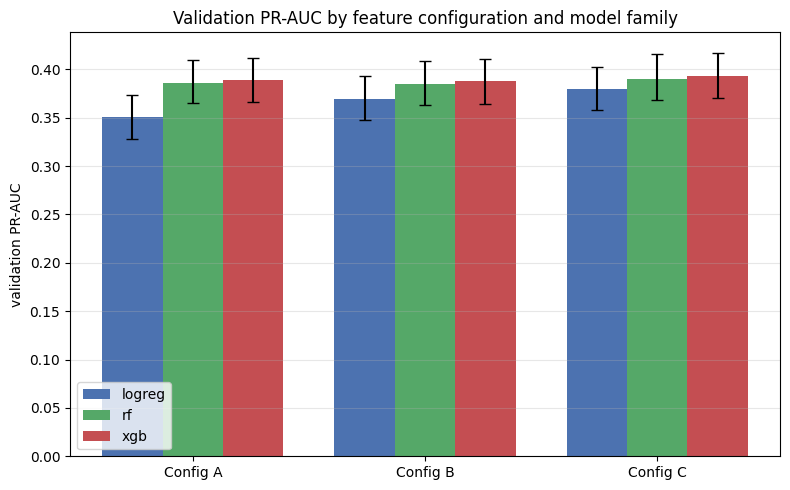

In [11]:
# Validation PR-AUC by configuration and family, with the bootstrap intervals as error
# bars. This figure summarises the whole configuration comparison in one view.
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(CONFIGS))
width = 0.26
colors = {"logreg": "#4C72B0", "rf": "#55A868", "xgb": "#C44E52"}
for j, family in enumerate(FAMILIES):
    keys = [f"{family}_{cfg}" for cfg in CONFIGS]
    vals = validation.loc[keys, "val_pr_auc"].to_numpy()
    err_lo = vals - validation.loc[keys, "pr_lo"].to_numpy()
    err_hi = validation.loc[keys, "pr_hi"].to_numpy() - vals
    ax.bar(x + (j - 1) * width, vals, width, yerr=[err_lo, err_hi], capsize=4,
           label=family, color=colors[family])
ax.set_xticks(x)
ax.set_xticklabels([f"Config {c}" for c in CONFIGS])
ax.set_ylabel("validation PR-AUC")
ax.set_title("Validation PR-AUC by feature configuration and model family")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Sensitivity check — does configuration C's LR value survive pruning the collinear twins?

Configuration C carries a collinear delinquency "twin" family, and `logreg_C` selects a
very heavy L2 penalty (`C = 3e-4`). The obvious question is whether C's advantage for
Logistic Regression is real or whether the shrinkage is merely masking redundancy. The
cell below re-tunes **only Logistic Regression** on configuration C with the redundant
twins removed, refits on the full training split, and compares the validation PR-AUC with
the full `logreg_C`. It is **self-contained** (it loads what it needs from the artifacts),
so it does **not** re-run the RF/XGB searches and does **not** change the selected models,
the nine `validation_metrics`, or any saved model — it only appends an
`lr_pruned_sensitivity` record to `tuned_params.json`.

In [12]:
# Self-contained LR pruned-Config-C collinearity sensitivity check. Loads the config-C
# matrices and the existing tuned_params.json, so it runs in isolation without the
# expensive RF/XGB searches above. Same LR grid / CV folds / seed as build_search.
import json
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import average_precision_score

SEED = 42
ARTIFACTS = Path("../artifacts")
TUNED_PATH = ARTIFACTS / "tuned_params.json"
tuned = json.loads(TUNED_PATH.read_text())

train_c = pd.read_parquet(ARTIFACTS / "train_configC.parquet")
val_c = pd.read_parquet(ARTIFACTS / "val_configC.parquet")
Xc_tr, yc_tr = train_c.drop(columns="target"), train_c["target"].to_numpy()
Xc_val, yc_val = val_c.drop(columns="target"), val_c["target"].to_numpy()

PRUNE = ["util_delinq_interaction", "delinquency_rate", "combined_delinq_flag",
         "zero_flag_past_due_30_59", "zero_flag_past_due_60_89", "zero_flag_past_due_90"]
pruned_cols = [c for c in Xc_tr.columns if c not in PRUNE]

LR_GRID = {"clf__C": [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2,
                      0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]}
def lr_pipeline(C=None):
    clf = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=5000,
                             class_weight="balanced", random_state=SEED,
                             **({"C": C} if C is not None else {}))
    return Pipeline([("scaler", StandardScaler()), ("clf", clf)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
pruned_search = GridSearchCV(lr_pipeline(), LR_GRID, scoring="average_precision",
                             cv=cv, n_jobs=-1).fit(Xc_tr[pruned_cols], yc_tr)
pruned_C = float(pruned_search.best_params_["clf__C"])
pruned_model = lr_pipeline(C=pruned_C).fit(Xc_tr[pruned_cols], yc_tr)
pruned_val_pr = float(average_precision_score(
    yc_val, pruned_model.predict_proba(Xc_val[pruned_cols])[:, 1]))

full_val_pr = float(next(r["val_pr_auc"] for r in tuned["validation_metrics"]
                         if r["pipeline"] == "logreg_C"))
full_C = float(tuned["logreg_C"]["best_params"]["clf__C"])

tuned["lr_pruned_sensitivity"] = {
    "full_features": list(Xc_tr.columns),
    "pruned_features": pruned_cols,
    "removed": PRUNE,
    "full_C": full_C,
    "pruned_C": pruned_C,
    "full_val_pr_auc": full_val_pr,
    "pruned_val_pr_auc": pruned_val_pr,
    "delta": pruned_val_pr - full_val_pr,
}
TUNED_PATH.write_text(json.dumps(tuned, indent=2))
print(f"logreg_C full   : C={full_C:g}  val PR-AUC={full_val_pr:.4f}  ({len(Xc_tr.columns)} feats)")
print(f"logreg_C pruned : C={pruned_C:g}  val PR-AUC={pruned_val_pr:.4f}  ({len(pruned_cols)} feats)")
print(f"delta (pruned - full) = {pruned_val_pr - full_val_pr:+.4f}  "
      "(delta near 0 / positive => the collinear twins add little for L2-regularised LR)")

logreg_C full   : C=0.0003  val PR-AUC=0.3792  (22 feats)
logreg_C pruned : C=3  val PR-AUC=0.3810  (16 feats)
delta (pruned - full) = +0.0019  (delta near 0 / positive => the collinear twins add little for L2-regularised LR)
